# Experimento 7.6 — Investimento: Maior Subsequência Crescente (LIS)
**Disciplina:** Análise de Algoritmos
**Tema:** 7.6 — Investimento

**Integrante:** Yan Pedro Façanha Brasileiro

---

## Contexto
Um analista financeiro deseja identificar períodos de crescimento sustentado no valor de uma ação ao longo do tempo. Dada uma série temporal contendo o preço diário do ativo, o objetivo é encontrar a maior sequência de dias em que os preços apresentaram tendência crescente, sem exigir que esses dias sejam consecutivos.

## Problema
Dado um vetor preenchido com os preços históricos de uma ação, determinar o **tamanho da maior subsequência estritamente crescente (LIS — *Longest Increasing Subsequence*) e recuperar os seus respectivos elementos** (os preços que compõem a tendência).

## Algoritmos Comparados
Para analisar experimentalmente o impacto do tamanho da entrada sobre o tempo médio de execução, implementamos e comparamos três abordagens:

1. **Algoritmo Ingênuo (Força Bruta | FB):** Explora e testa exaustivamente todas as subsequências possíveis para encontrar a maior. Complexidade: $O(2^n)$.
2. **Programação Dinâmica Recursiva com Memoização (PD REC):** Abordagem *Top-Down* que divide o problema recursivamente e armazena os estados em cache para evitar recomputações redundantes. Complexidade: $O(n^2)$.
3. **Programação Dinâmica Iterativa (PD IT):** Abordagem *Bottom-Up* que preenche uma tabela de decisões sequencialmente e reconstrói o caminho ótimo. Complexidade: $O(n^2)$.

## Implementação dos Algoritmos

In [1]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

def lis_iterativo(precos):
    n = len(precos)
    if n == 0: return 0, []
    dp = [1] * n
    parent = [-1] * n
    for i in range(1, n):
        for j in range(i):
            if precos[i] > precos[j] and dp[j] + 1 > dp[i]:
                dp[i] = dp[j] + 1
                parent[i] = j
    max_idx = int(np.argmax(dp))
    max_len = dp[max_idx]
    solucao = []
    curr = max_idx
    while curr != -1:
        solucao.append(precos[curr])
        curr = parent[curr]
    solucao.reverse()
    return max_len, solucao

def lis_recursivo_memo(precos):
    n = len(precos)
    if n == 0: return 0, []
    memo = {}
    decisoes = {}
    def lcs_td(idx, prev_idx):
        if idx == n: return 0
        state = (idx, prev_idx)
        if state in memo: return memo[state]
        ans_exclude = lcs_td(idx + 1, prev_idx)
        ans_include = 0
        if prev_idx == -1 or precos[idx] > precos[prev_idx]:
            ans_include = 1 + lcs_td(idx + 1, idx)
        if ans_include > ans_exclude:
            memo[state] = ans_include
            decisoes[state] = True
        else:
            memo[state] = ans_exclude
            decisoes[state] = False
        return memo[state]
    max_len = lcs_td(0, -1)
    solucao = []
    curr_idx, curr_prev = 0, -1
    while curr_idx < n:
        state = (curr_idx, curr_prev)
        if decisoes.get(state, False):
            solucao.append(precos[curr_idx])
            curr_prev = curr_idx
        curr_idx += 1
    return max_len, solucao

def lis_ingenuo(precos):
    n = len(precos)
    def helper(idx, prev_idx):
        if idx == n: return 0, []
        len_ex, seq_ex = helper(idx + 1, prev_idx)
        len_inc, seq_inc = 0, []
        if prev_idx == -1 or precos[idx] > precos[prev_idx]:
            l, s = helper(idx + 1, idx)
            len_inc = 1 + l
            seq_inc = [precos[idx]] + s
        if len_inc > len_ex: return len_inc, seq_inc
        return len_ex, seq_ex
    return helper(0, -1)

## Coleta dos Tempos

In [2]:
import sys
import time
import random
import numpy as np

# Aumenta o limite máximo de recursão do Python de forma segura
sys.setrecursionlimit(10000)

def gerador_entradas(tamanho):
    # Valores caóticos e independentes para simular a volatilidade real do mercado
    return [random.randint(10, 500) for _ in range(tamanho)]

def formatar_vetor(vetor, forcar_completo=False):
    """
    Formata o vetor de acordo com a etapa.
    Se forcar_completo for True ou o vetor for pequeno, mostra inteiro.
    Caso contrário, adota o padrão visual: [6 primeiros, ..., 4 últimos]
    """
    if forcar_completo or len(vetor) <= 12:
        return str(vetor)

    primeiros = ", ".join(map(str, vetor[:6]))
    ultimos = ", ".join(map(str, vetor[-4:]))
    return f"[{primeiros}, ..., {ultimos}]"

# CONFIGURAÇÃO DE TAMANHOS CALIBRADA (15 v 15 | Máximo 1500)
tamanhos_pequenos = list(range(10, 25, 1)) # 15 testes: n=10 até n=24
tamanhos_grandes = [int(x) for x in np.linspace(100, 1500, 15)] # 15 testes: n=100 até n=1500

tempos_pequenos = {'ingenuo': [], 'recursivo': [], 'iterativo': []}
tempos_grandes = {'recursivo': [], 'iterativo': []}

# Códigos de Cores ANSI para o terminal
RESET = "\033[0m"
BOLD = "\033[1m"
RED = "\033[91m"
GREEN = "\033[92m"
BLUE = "\033[94m"
CYAN = "\033[96m"
BG_GREEN = "\033[1;32m"

print(f"{BOLD}Configuração Ativa:{RESET} {len(tamanhos_pequenos)} tamanhos pequenos + {len(tamanhos_grandes)} tamanhos grandes = {BOLD}{len(tamanhos_pequenos)+len(tamanhos_grandes)} tamanhos totais.{RESET}")
print("==========================================================================================")
print(f"--- {CYAN}ETAPA 1: ENTRADAS PEQUENAS (COMPARAÇÃO COM FORÇA BRUTA){RESET} ---")
print("==========================================================================================\n")

# Dicionário para guardar os exemplos da etapa 1
exemplos_etapa1 = {}

for idx, n in enumerate(tamanhos_pequenos):
    acumulado_ing, acumulado_rec, acumulado_ite = 0, 0, 0

    for i in range(10):
        entrada_compartilhada = gerador_entradas(n)

        # 1. Força Bruta (Ingênuo)
        t0 = time.perf_counter()
        l_ing, seq_ing = lis_ingenuo(entrada_compartilhada)
        acumulado_ing += (time.perf_counter() - t0)

        # 2. PD Recursiva
        t0 = time.perf_counter()
        l_rec, seq_rec = lis_recursivo_memo(entrada_compartilhada)
        acumulado_rec += (time.perf_counter() - t0)

        # 3. PD Iterativa
        t0 = time.perf_counter()
        l_ite, seq_ite = lis_iterativo(entrada_compartilhada)
        acumulado_ite += (time.perf_counter() - t0)

        assert l_ite == l_rec == l_ing, f"Erro de corretude no tamanho em n={n}!"

        # Guarda o exemplo do primeiro (N=10) e do último (N=24)
        if (idx == 0 or idx == len(tamanhos_pequenos) - 1) and i == 0:
            exemplos_etapa1[n] = {
                'entrada': entrada_compartilhada.copy(),
                'l_ing': l_ing, 'seq_ing': seq_ing.copy(),
                'l_rec': l_rec, 'seq_rec': seq_rec.copy(),
                'l_ite': l_ite, 'seq_ite': seq_ite.copy()
            }

    media_ing_ms = (acumulado_ing / 10) * 1000
    media_rec_ms = (acumulado_rec / 10) * 1000
    media_ite_ms = (acumulado_ite / 10) * 1000

    tempos_pequenos['ingenuo'].append(acumulado_ing / 10)
    tempos_pequenos['recursivo'].append(acumulado_rec / 10)
    tempos_pequenos['iterativo'].append(acumulado_ite / 10)

    print(f"📊 Teste {idx+1:2d}/15 | n={BOLD}{n:2d}{RESET} | Tempo Médio -> "
          f"FB: {RED}{media_ing_ms:8.3f}ms{RESET} | "
          f"PD Rec: {BLUE}{media_rec_ms:5.3f}ms{RESET} | "
          f"PD It: {GREEN}{media_ite_ms:5.3f}ms{RESET} | "
          f"Status: {BG_GREEN}OK (Respostas Iguais){RESET}")

# Print consolidado dos exemplos da Etapa 1 (Forçando exibição 100% completa)
print("\n" + "-" * 90)
print(f"🔍 {BOLD}{CYAN}PAINEL DE VERIFICAÇÃO DE CORRETUDE EXPLÍCITA (ETAPA 1){RESET}")
print("-" * 90)
for n in [10, 24]:
    if n in exemplos_etapa1:
        ex = exemplos_etapa1[n]
        print(f"🔹 [EXEMPLO DE VERIFICAÇÃO DE CORRETUDE - N = {n}]")
        print(f"  » Preços (Entrada):        {formatar_vetor(ex['entrada'], forcar_completo=True)}")
        print(f"  » Saída Força Bruta:       Tamanho = {ex['l_ing']}, Sequência = {formatar_vetor(ex['seq_ing'], forcar_completo=True)}")
        print(f"  » Saída PD Recursiva Memo: Tamanho = {ex['l_rec']}, Sequência = {formatar_vetor(ex['seq_rec'], forcar_completo=True)}")
        print(f"  » Saída PD Iterativa:      Tamanho = {ex['l_ite']}, Sequência = {formatar_vetor(ex['seq_ite'], forcar_completo=True)}")
        print("-" * 90)


print("\n==========================================================================================")
print(f"--- {CYAN}ETAPA 2: ESCALA MACRO ATÉ 1500 (APENAS ABORDAGENS DE PROG. DINÂMICA){RESET} ---")
print("==========================================================================================\n")

# Dicionário para guardar os exemplos da escala macro
exemplos_etapa2 = {}

for idx, n in enumerate(tamanhos_grandes):
    acumulado_rec, acumulado_ite = 0, 0

    for i in range(10):
        entrada_compartilhada = gerador_entradas(n)

        # 1. PD Recursiva
        t0 = time.perf_counter()
        l_rec, seq_rec = lis_recursivo_memo(entrada_compartilhada)
        acumulado_rec += (time.perf_counter() - t0)

        # 2. PD Iterativa
        t0 = time.perf_counter()
        l_ite, seq_ite = lis_iterativo(entrada_compartilhada)
        acumulado_ite += (time.perf_counter() - t0)

        assert l_ite == l_rec, f"Erro de corretude no tamanho em n={n}!"

        # Guarda o exemplo do primeiro (N=100) e do último (N=1500)
        if (idx == 0 or idx == len(tamanhos_grandes) - 1) and i == 0:
            exemplos_etapa2[n] = {
                'entrada': entrada_compartilhada.copy(),
                'l_rec': l_rec, 'seq_rec': seq_rec.copy(),
                'l_ite': l_ite, 'seq_ite': seq_ite.copy()
            }

    media_rec_ms = (acumulado_rec / 10) * 1000
    media_ite_ms = (acumulado_ite / 10) * 1000

    tempos_grandes['recursivo'].append(acumulado_rec / 10)
    tempos_grandes['iterativo'].append(acumulado_ite / 10)

    print(f"📊 Teste {idx+1:2d}/15 | n={BOLD}{n:4d}{RESET} | Tempo Médio -> "
          f"FB: {RED}   N/A   {RESET} | "
          f"PD Rec: {BLUE}{media_rec_ms:8.3f}ms{RESET} | "
          f"PD It: {GREEN}{media_ite_ms:8.3f}ms{RESET} | "
          f"Status: {BG_GREEN}OK (Respostas Iguais){RESET}")

# Print consolidado dos exemplos da Etapa 2 (Utilizando formato resumido dinâmico)
print("\n" + "-" * 90)
print(f"🔍 {BOLD}{CYAN}PAINEL DE VERIFICAÇÃO DE CORRETUDE EXPLÍCITA (ETAPA 2){RESET}")
print("-" * 90)
for n in [tamanhos_grandes[0], tamanhos_grandes[-1]]:
    if n in exemplos_etapa2:
        ex = exemplos_etapa2[n]
        print(f"🔸 [EXEMPLO DE VERIFICAÇÃO DE CORRETUDE - N = {n}]")
        print(f"  » Preços (Entrada):        {formatar_vetor(ex['entrada'], forcar_completo=False)}")
        print(f"  » Saída Força Bruta:       Tamanho = N/A, Sequência = N/A")
        print(f"  » Saída PD Recursiva Memo: Tamanho = {ex['l_rec']}, Sequência = {formatar_vetor(ex['seq_rec'], forcar_completo=False)}")
        print(f"  » Saída PD Iterativa:      Tamanho = {ex['l_ite']}, Sequência = {formatar_vetor(ex['seq_ite'], forcar_completo=False)}")
        print("-" * 90)

Configuração Ativa: 15 tamanhos pequenos + 15 tamanhos grandes = 30 tamanhos totais.
--- ETAPA 1: ENTRADAS PEQUENAS (COMPARAÇÃO COM FORÇA BRUTA) ---

📊 Teste  1/15 | n=10 | Tempo Médio -> FB:    0.091ms | PD Rec: 0.092ms | PD It: 0.151ms | Status: OK (Respostas Iguais)
📊 Teste  2/15 | n=11 | Tempo Médio -> FB:    0.400ms | PD Rec: 0.043ms | PD It: 0.018ms | Status: OK (Respostas Iguais)
📊 Teste  3/15 | n=12 | Tempo Médio -> FB:    0.086ms | PD Rec: 0.044ms | PD It: 0.015ms | Status: OK (Respostas Iguais)
📊 Teste  4/15 | n=13 | Tempo Médio -> FB:    0.310ms | PD Rec: 0.090ms | PD It: 0.019ms | Status: OK (Respostas Iguais)
📊 Teste  5/15 | n=14 | Tempo Médio -> FB:    0.138ms | PD Rec: 0.056ms | PD It: 0.020ms | Status: OK (Respostas Iguais)
📊 Teste  6/15 | n=15 | Tempo Médio -> FB:    0.821ms | PD Rec: 0.541ms | PD It: 0.053ms | Status: OK (Respostas Iguais)
📊 Teste  7/15 | n=16 | Tempo Médio -> FB:    1.038ms | PD Rec: 0.117ms | PD It: 0.042ms | Status: OK (Respostas Iguais)
📊 Teste  8

## Geração dos Gráficos


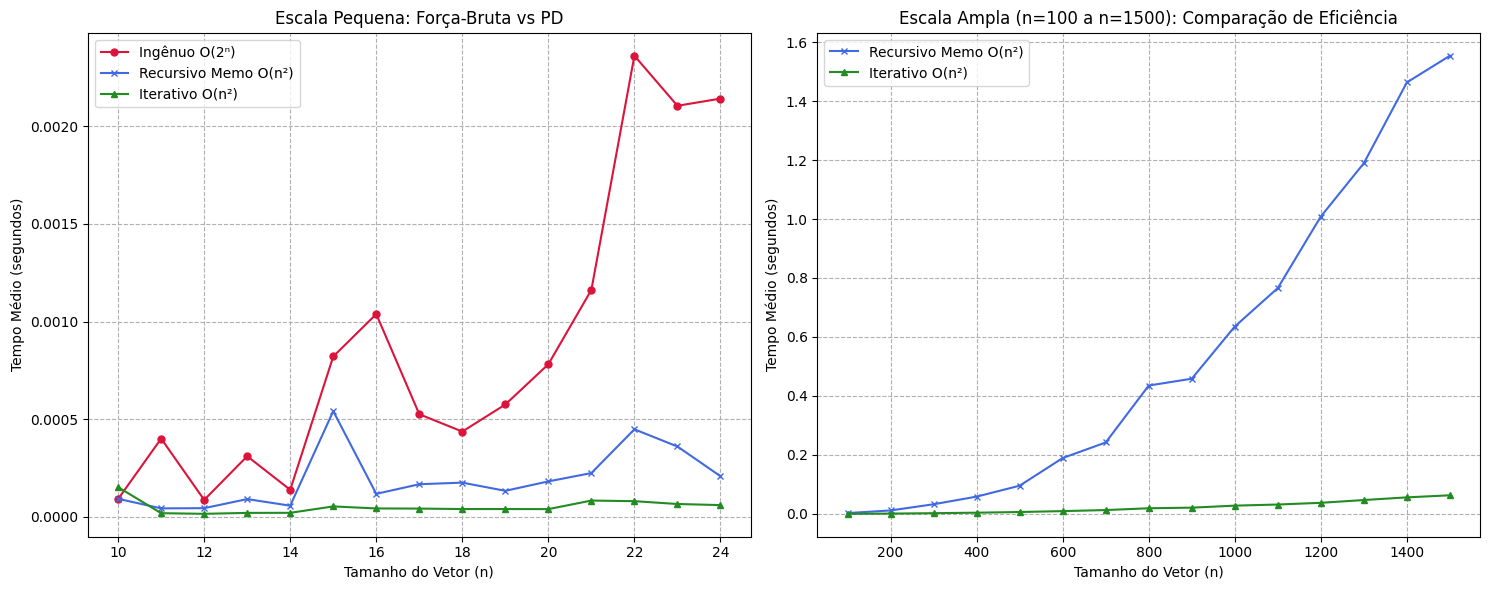

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Gráfico 1: Escala Reduzida
plt.subplot(1, 2, 1)
plt.plot(tamanhos_pequenos, tempos_pequenos['ingenuo'], label='Ingênuo O(2ⁿ)', color='crimson', marker='o', markersize=5)
plt.plot(tamanhos_pequenos, tempos_pequenos['recursivo'], label='Recursivo Memo O(n²)', color='royalblue', marker='x', markersize=5)
plt.plot(tamanhos_pequenos, tempos_pequenos['iterativo'], label='Iterativo O(n²)', color='forestgreen', marker='^', markersize=5)
plt.title('Escala Pequena: Força-Bruta vs PD')
plt.xlabel('Tamanho do Vetor (n)')
plt.ylabel('Tempo Médio (segundos)')
plt.legend()
plt.grid(True, linestyle='--')

# Gráfico 2: Escala Macro (Atualizado de n=100 até n=1500 com 15 pontos)
plt.subplot(1, 2, 2)
plt.plot(tamanhos_grandes, tempos_grandes['recursivo'], label='Recursivo Memo O(n²)', color='royalblue', marker='x', markersize=5)
plt.plot(tamanhos_grandes, tempos_grandes['iterativo'], label='Iterativo O(n²)', color='forestgreen', marker='^', markersize=5)
plt.title('Escala Ampla (n=100 a n=1500): Comparação de Eficiência')
plt.xlabel('Tamanho do Vetor (n)')
plt.ylabel('Tempo Médio (segundos)')
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()